In [1]:
!pip install rdkit

In [11]:
import pandas as pd
import numpy as np
df = pd.read_csv("qm133885_properties.csv")
df["H"]=y
corr = df.corr()["H"].abs().sort_values(ascending=False)
selected_features = corr[corr>0.75].index
X_selected = X_df[selected_features]
print("Selected descriptors:",len(selected_features))
print(selected_features)
X_selected_df = pd.DataFrame(X_selected,columns=selected_features)
X_selected_df.to_csv("perrsoncorr.0.75.csv",index=False)

Selected descriptors: 4
Index(['H', 'U', 'U0', 'G'], dtype='object')


Total RDKIT descriptors: 209
Index(['MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumHeteroatoms'], dtype='object')
Total descriptors used:           MolWt  HeavyAtomMolWt  ExactMolWt  NumHeteroatoms
0        16.043          12.011   16.031300               0
1        17.031          14.007   17.026549               1
2        18.015          15.999   18.010565               1
3        26.038          24.022   26.015650               0
4        27.026          26.018   27.010899               1
...         ...             ...         ...             ...
133880  121.139         114.083  121.052764               2
133881  121.139         114.083  121.052764               2
133882  120.155         112.091  120.068748               2
133883  119.167         110.095  119.073499               1
133884  121.139         114.083  121.052764               2

[133885 rows x 4 columns]
Training range: -549.919077 to -250.472502
Testing range: -714.559209 to -40.475117
Training samples: 133357
Testing 

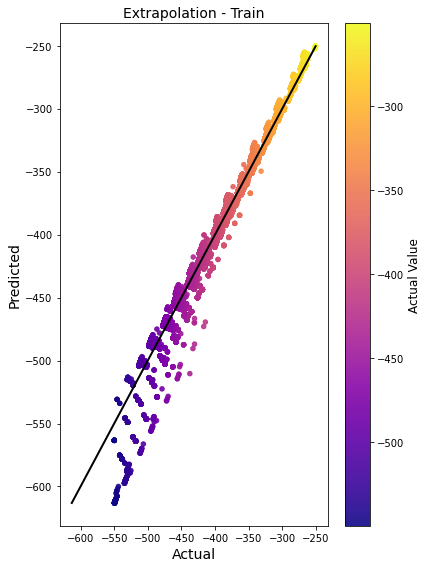

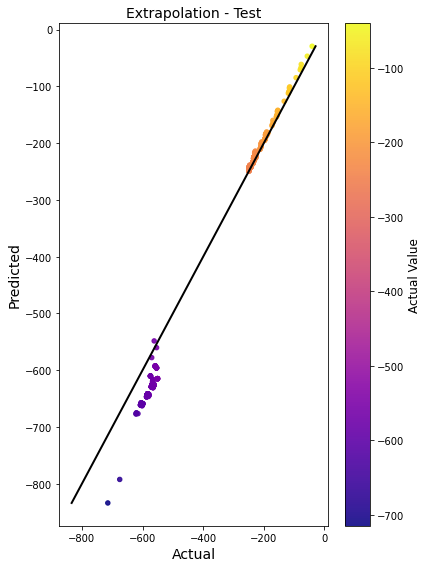

Test R² = 0.9425
Test MSE = 1869.3052


In [3]:
#########################################################
# CHEMCAL DESCRIPTOR-RIDGE REGRESSION(With feature selection)
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import Descriptors

descriptor_names = [name for name,func in Descriptors.descList]
print("Total RDKIT descriptors:", len(Descriptors.descList))

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
X_df = pd.read_csv("selected_descriptors.csv")
X_df = X_df.drop(columns=["SMILES"])
smiles = data["SMILES"]

#==========================================
#CHEMICAL DESCRIPTOR WITH SELECTED FEATURES
#==========================================
y = data["H"].values

print(X_df.columns)
print("Total descriptors used:",X_df)

# ===============================
# EXTRAPOLATION SPLIT
# ===============================

train_mask = (y >= -550) & (y <= -250)
test_mask = ~train_mask

X_train = X_df[train_mask]
y_train = y[train_mask]

X_test = X_df[test_mask]
y_test = y[test_mask]

print("Training range:", y_train.min(), "to", y_train.max())
print("Testing range:", y_test.min(), "to", y_test.max())

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ===============================
# USE ONLY 100% OF TRAINING DATA
# ===============================
sub_size = int(1.00 * len(X_train))
X_train_sub = X_train
y_train_sub = y_train

print("Training points used:", len(X_train_sub))

# ===============================
# SCALE FEATURES
# ===============================

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train_sub)
X_test_scaled = x_scaler.transform(X_test)

# ===============================
# RIDGE REGRESSION
# ===============================

ridge = Ridge(alpha=1e-4)

ridge.fit(X_train_scaled, y_train_sub)

# Predictions
y_pred_train = ridge.predict(X_train_scaled)
y_pred_test = ridge.predict(X_test_scaled)
# Residuals
errors = np.abs(y_train_sub - y_pred_train)

# Indices of the 10 largest errors
top10_idx = np.argsort(errors)[-10:]

print("Two most deviated molecules:\n")

for idx in top10_idx:
    print("SMILES           :", smiles[train_mask][:sub_size].iloc[idx])
    print("Actual H         :", y_train_sub[idx])
    print("Predicted H      :", y_pred_train[idx])
    print("Absolute Error   :", errors[idx])
    print("-"*50)

# ===============================
# METRICS
# ===============================

mse_train = mean_squared_error(y_train_sub, y_pred_train)
r2_train = r2_score(y_train_sub, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nResults")
print("-"*40)
print(f"Train MSE : {mse_train:.4f}")
print(f"Train R²  : {r2_train:.4f}")
print(f"Test MSE  : {mse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")

#===================================
#PARITY PLOT
#==================================

plt.figure(figsize=(6,8))

scatter = plt.scatter(
    y_train_sub,
    y_pred_train,
    c=y_train_sub,          # Color by actual enthalpy
    cmap='plasma',
    s=20,
    alpha=0.9
)

min_val = min(y_train_sub.min(), y_pred_train.min())
max_val = max(y_train_sub.max(), y_pred_train.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

plt.xlabel('Actual', fontsize=14)
plt.ylabel('Predicted', fontsize=14)

plt.title('Extrapolation - Train', fontsize=14)
plt.savefig("CD_Train_Parity(FS)_-550=-250.png",
            dpi=600,
            bbox_inches='tight')

cbar = plt.colorbar(scatter)
cbar.set_label('Actual Value', fontsize=12)

plt.tight_layout()
plt.figure(figsize=(6,8))

scatter = plt.scatter(y_test, y_pred_test, c=y_test, cmap='plasma', s=20, alpha=0.9)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

plt.xlabel('Actual', fontsize=14)
plt.ylabel('Predicted', fontsize=14)

plt.title('Extrapolation - Test', fontsize=14)

cbar = plt.colorbar(scatter)
cbar.set_label('Actual Value', fontsize=12)

plt.tight_layout()

plt.savefig("CD_Test_Parity(FS)_-550=-250.png",
            dpi=600,
            bbox_inches='tight')

plt.show()

# Print test metrics
print(f"Test R² = {r2_test:.4f}")
print(f"Test MSE = {mse_test:.4f}")
vmin = min(y_train_sub.min(), y_test.min())
vmax = max(y_train_sub.max(), y_test.max())

plt.show()

In [ ]:
#########################################################
# CHEMCAL DESCRIPTOR-RIDGE REGRESSION(Without feature selection)
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import Descriptors

descriptor_names = [name for name,func in Descriptors.descList]
print("Total RDKIT descriptors:", len(Descriptors.descList))

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
smiles = data["SMILES"]
y = data["H"].values
print("STARTED")
# ===============================
# chemical descriptor(no feature selection)
# ===============================
descriptor_values = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        values = [func(mol) for name,func in Descriptors.descList]
    else:
        values = [np.nan]*len(descriptor_name)
    
    descriptor_values.append(values)
    
X_df = pd.DataFrame(descriptor_values, columns=descriptor_names)
print("success")

# ===============================
# EXTRAPOLATION SPLIT
# Train: H between -460 and -360
# Test: H > -360 & H < -460
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train = X.df[train_mask]
y_train = y[train_mask]

X_test = X.df[test_mask]
y_test = y[test_mask]

print("Training range:", y_train.min(), "to", y_train.max())
print("Testing range:", y_test.min(), "to", y_test.max())

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ===============================
# USE ONLY 100% OF TRAINING DATA
# ===============================

X_train_sub = X_train
y_train_sub = y_train

print("Training points used:", len(X_train_sub))

# ===============================
# SCALE FEATURES
# ===============================

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train_sub)
X_test_scaled = x_scaler.transform(X_test)

# ===============================
# RIDGE REGRESSION
# ===============================

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train_sub)

# Predictions
y_pred_train = ridge.predict(X_train_scaled)
y_pred_test = ridge.predict(X_test_scaled)
# Residuals
errors = np.abs(y_train_sub - y_pred_train)

# Indices of the 10 largest errors
#top10_idx = np.argsort(errors)[-10:]

#print("Two most deviated molecules:\n")

#for idx in top10_idx:
    #print("SMILES           :", smiles[train_mask][:sub_size][idx])
    #("Actual H         :", y_train_sub[idx])
    #print("Predicted H      :", y_pred_train[idx])
    #("Absolute Error   :", errors[idx])
    #print("-"*50)

# ===============================
# METRICS
# ===============================

mse_train = mean_squared_error(y_train_sub, y_pred_train)
r2_train = r2_score(y_train_sub, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nResults")
print("-"*40)
print(f"Train MSE : {mse_train:.4f}")
print(f"Train R²  : {r2_train:.4f}")
print(f"Test MSE  : {mse_test:.4f}")
print(f"Test R²   : {r2_test:.4f}")

#===================================
#PARITY PLOT
#==================================

plt.figure(figsize=(6,8))

scatter = plt.scatter(
    y_train_sub,
    y_pred_train,
    c=y_train_sub,          # Color by actual enthalpy
    cmap='plasma',
    s=20,
    alpha=0.9
)

min_val = min(y_train_sub.min(), y_pred_train.min())
max_val = max(y_train_sub.max(), y_pred_train.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

plt.xlabel('Actual', fontsize=14)
plt.ylabel('Predicted', fontsize=14)

plt.title('Extrapolation - Train', fontsize=14)

cbar = plt.colorbar(scatter)
cbar.set_label('Actual Value', fontsize=12)

plt.tight_layout()
plt.figure(figsize=(6,8))

scatter = plt.scatter(y_test, y_pred_test, c=y_test, cmap='plasma', s=20, alpha=0.9)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'k-',
         linewidth=2)

plt.xlabel('Actual', fontsize=14)
plt.ylabel('Predicted', fontsize=14)

plt.title('Extrapolation - Test', fontsize=14)

cbar = plt.colorbar(scatter)
cbar.set_label('Actual Value', fontsize=12)

plt.tight_layout()

plt.savefig("Train_Parity.png",
            dpi=600,
            bbox_inches='tight')

plt.show()

# Print test metrics
print(f"Test R² = {r2_test:.4f}")
print(f"Test MSE = {mse_test:.4f}")
vmin = min(y_train_sub.min(), y_test.min())
vmax = max(y_train_sub.max(), y_test.max())

plt.savefig("Test_Parity.png",
            dpi=600,
            bbox_inches='tight')

plt.show()